In [ ]:
# Instalación de ultralytics y dependencias
%pip install ultralytics roboflow
import ultralytics
ultralytics.checks()  # Verifica entorno y versiones

Ultralytics 8.3.225  Python-3.13.5 torch-2.8.0+cpu CPU (Intel Core i7-8665U 1.90GHz)
Setup complete  (8 CPUs, 15.7 GB RAM, 308.2/475.6 GB disk)


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="89B4O4DKe244EJPDkke2")
project = rf.workspace("bulentkaradeniz-blacksea").project("sleep_detection-5tglp")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sleep_Detection-1 in yolov8:: 100%|██████████| 10154/10154 [00:14<00:00, 691.19it/s]


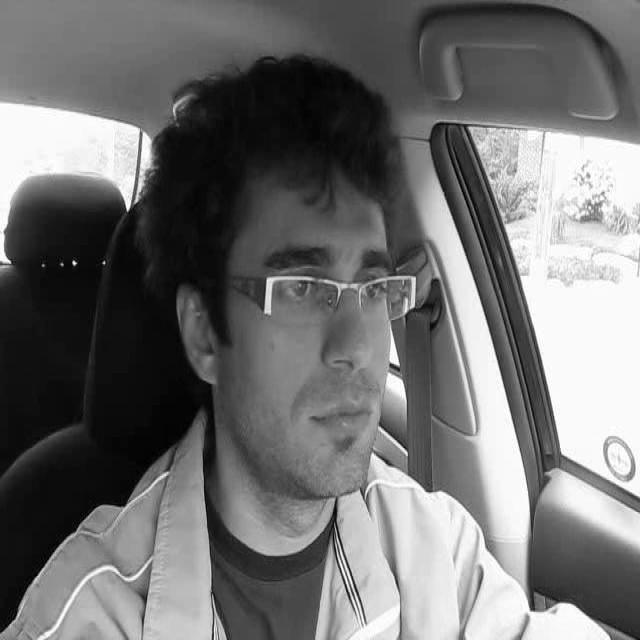

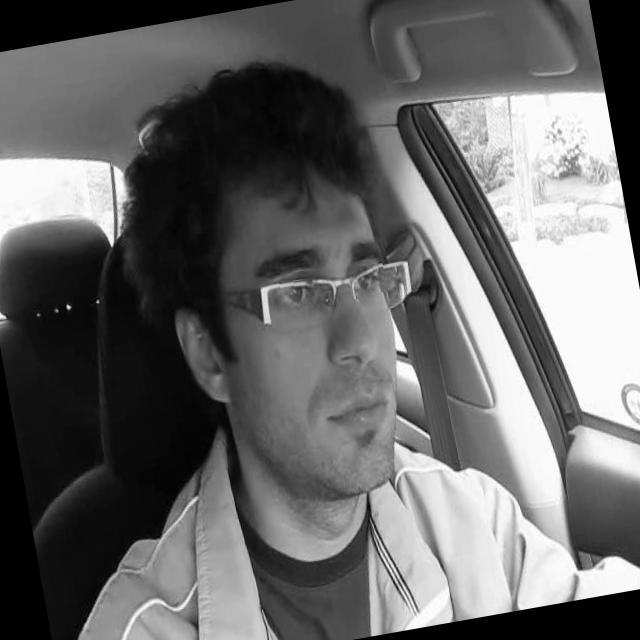

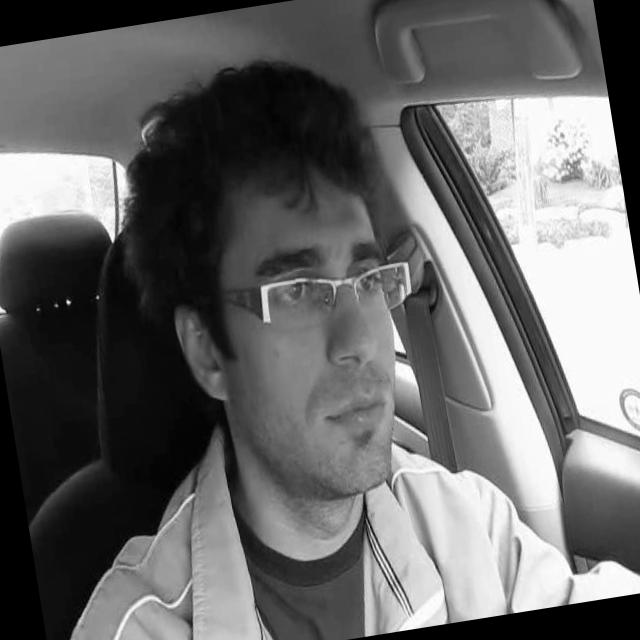

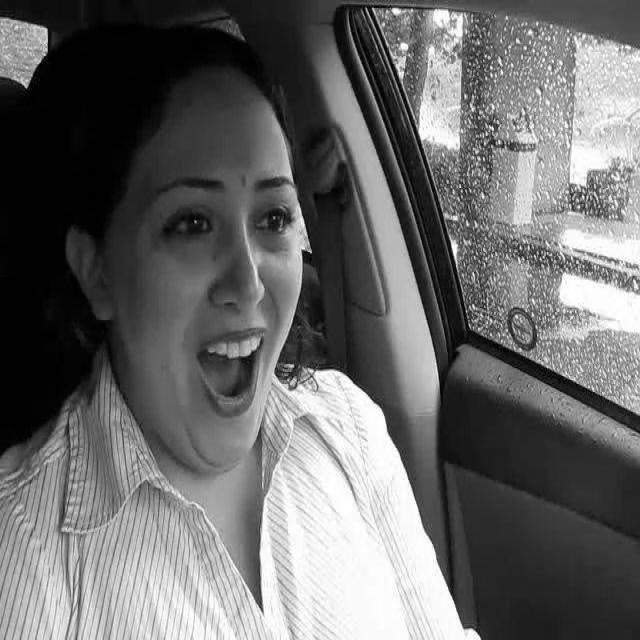

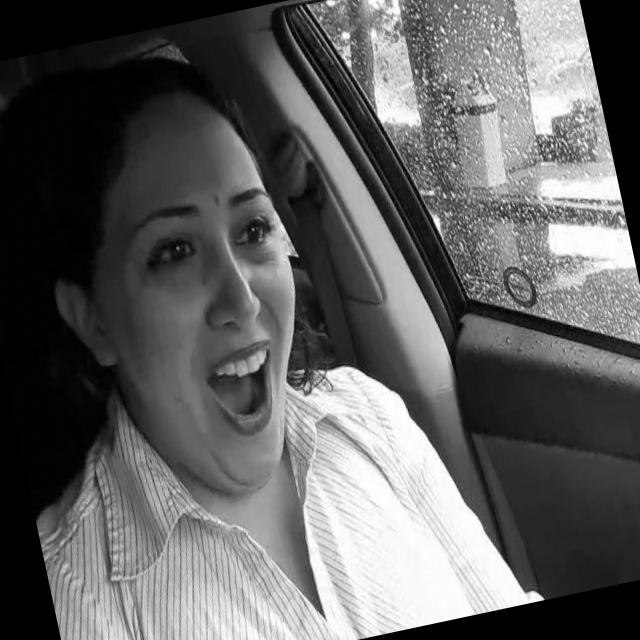

In [ ]:
# Muestra imágenes de entrenamiento
import os
from PIL import Image

img_dir = r'Sleep_Detection-1/train/images'
sample_imgs = os.listdir(img_dir)[:5]
for img_name in sample_imgs:
    display(Image.open(os.path.join(img_dir, img_name)))

In [ ]:
# Entrenamiento YOLOv8
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

In [ ]:
# Entrenar el modelo YOLOv8 con el dataset preparado, ajustando hiperparámetros para mejor desempeño
results = model.train(
    data='Sleep_Detection-1/data.yaml',          # Ruta a la carpeta con la estructura de datos clasificados
    epochs=10,               # Número de épocas de entrenamiento
    imgsz=736,               # Tamaño de las imágenes (mayor que el original para mejores resultados)
    batch=32,                # Tamaño del lote/batch (optimal para GPU)
    project='open_close_detect', 
    name='yolov8n_exp',
    patience=10,             # Paciencia (early stopping) para evitar sobreajuste
    optimizer='AdamW',       # Se utiliza el optimizador AdamW para mejor convergencia
    lr0=0.001,               # Learning rate inicial
    lrf=0.01,                # Learning rate final
    augment=True,            # Usa data augmentation para mejorar robustez del aprendizaje
    save=True,               # Guarda checkpoints de entrenamiento
    plots=True,              # Genera y guarda gráficas de entrenamiento
    verbose=True,            # Muestra mensajes detallados durante el proceso
    device=0                 # Usa GPU (0) si está disponible, 'cpu' en caso contrario
)

# Imprimir confirmación del entrenamiento completado
print("✓ Entrenamiento completado")


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Sleep_Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_exp2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10, perspective=0.0, plots=True, pos

In [6]:
import pandas as pd
df = pd.read_csv('open_close_detect/yolov8n_exp/results.csv')
display(df.head())

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,98.8025,1.36389,0.65441,1.59848,0.92549,0.91801,0.96903,0.51939,1.60042,0.71255,1.91556,0.067237,0.000331,0.000331
1,2,188.3650,1.33966,0.62420,1.59224,0.94235,0.94338,0.96383,0.44906,1.75639,0.69396,2.17646,0.034172,0.000599,0.000599
2,3,279.5130,1.32641,0.61556,1.57689,0.93613,0.94126,0.97403,0.53058,1.59389,0.65095,1.88746,0.001040,0.000800,0.000800
3,4,370.7610,1.32299,0.60462,1.57430,0.94520,0.92735,0.96979,0.53421,1.53128,0.65652,1.82847,0.000703,0.000703,0.000703
4,5,462.7990,1.30151,0.58226,1.55252,0.94693,0.94030,0.98200,0.53957,1.54199,0.62441,1.82611,0.000604,0.000604,0.000604


In [ ]:
# Evaluación en el val set
best_model = YOLO('open_close_detect/yolov8n_exp/weights/best.pt')
metrics = best_model.val(data="Sleep_Detection-1/data.yaml", imgsz=640)
print(metrics)  # Imprime mapa, precision, recall, confusion matrix


Ultralytics 8.3.225  Python-3.13.5 torch-2.8.0+cpu CPU (Intel Core i7-8665U 1.90GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2.50.6 MB/s, size: 35.2 KB)
val: Scanning C:\Users\cardo\01_Desarrollo\Proyectos_Personales\blink_detection_with_image_processing\trainning\Sleep_Detection-1\valid\labels... 423 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 423/423 142.7it/s 3.0s0.1s
val: New cache created: C:\Users\cardo\01_Desarrollo\Proyectos_Personales\blink_detection_with_image_processing\trainning\Sleep_Detection-1\valid\labels.cache
WARNING Box and segment counts should be equal, but got len(segments) = 3, len(boxes) = 606. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━


image 1/1 c:\Users\cardo\01_Desarrollo\Proyectos_Personales\blink_detection_with_image_processing\trainning\Sleep_Detection-1\valid\images\867_jpg.rf.5d3ba6e68f332bb7b6f10f69f12ca7d8.jpg: 736x736 2 0s, 270.1ms
Speed: 30.5ms preprocess, 270.1ms inference, 2.1ms postprocess per image at shape (1, 3, 736, 736)
Results saved to C:\Users\cardo\01_Desarrollo\Proyectos_Personales\blink_detection_with_image_processing\trainning\runs\detect\predict2


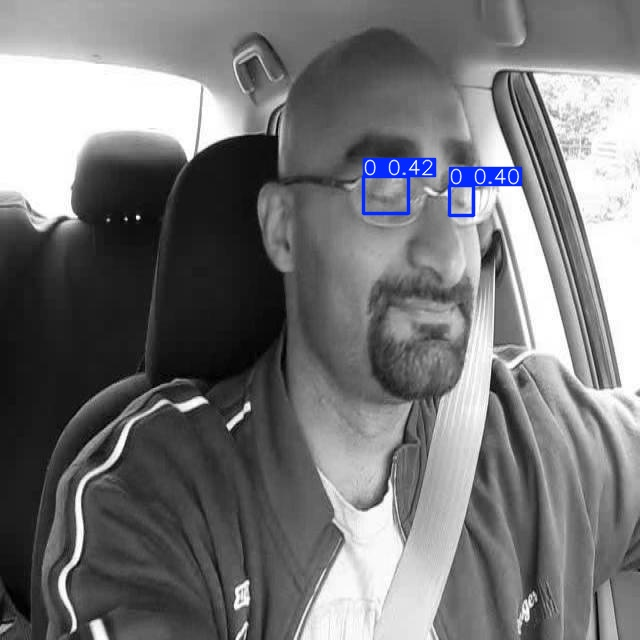

In [ ]:
# Evaluacion en imagen no vista
img_test = r'Sleep_Detection-1\valid\images\867_jpg.rf.5d3ba6e68f332bb7b6f10f69f12ca7d8.jpg'  # Pon aquí tu imagen

results = best_model(img_test, save=True, conf=0.35)
result = results[0]  # Extrae el resultado de la imagen

from IPython.display import Image as IPImage, display
import os

# Visualiza la imagen generada con boxes y etiquetas (se guarda en result.save_dir)
pred_path = os.path.join(result.save_dir, os.path.basename(img_test))
display(IPImage(filename=pred_path))
